# 🔍 Credit Card Fraud Detection — Notebook 1: EDA & Data Preparation
**Statistics & Probability — Final Research Project**
Team Nekat Part 100 · Felicia Sword · 0706012410012 · May 2026

---
This notebook covers **exploratory data analysis (EDA) and data preparation**: it engineers the features, explores the data, and saves a cleaned dataset (`data/data_clean.csv`) that **Notebook 2** uses for the KNN vs Logistic Regression analysis.


## Background & Research Design

**Problem.** Credit-card fraud is one of the most significant threats in the global digital-finance ecosystem. The U.S. Federal Trade Commission reported consumer losses of more than **USD 8.8 billion** to fraud in 2022, up 30% year-on-year (FTC, 2023). In Indonesia, OJK recorded losses of **Rp 7.8 trillion** from digital financial fraud in November 2024, alongside a 550% surge in cyber-crime (OJK, 2026). The core technical challenge is **severe class imbalance** — real fraud rates are typically under 1% — which biases classifiers toward the majority (legitimate) class.

**Research question.** Among two standard classification algorithms — **K-Nearest Neighbor (KNN)** and **Logistic Regression (LR)** — which gives the best performance for classifying credit-card fraud on a highly imbalanced dataset, and how does applying **SMOTE** affect their relative performance?

**Variables.**
- **Y** — `is_fraud` (1 = fraud, 0 = legitimate)
- **X1–X8** — `category`, `gender`, `age`, `city_pop`, `hour`, `day_of_week`, `is_weekend`, `distance` (the registered design)
- **X9** — `amt` (transaction amount): *an extension beyond the registered X1–X8 set, included because it is the dominant fraud signal in this dataset; its impact is analysed explicitly in the conclusions.*

**Method.** Stratified 80:20 train-test split; one-hot encoding for `category` and `day_of_week`, label encoding for `gender`, and z-score standardisation of numeric features. Optimal *k* for KNN is chosen by 5-fold stratified cross-validation. Each algorithm is evaluated under two conditions — **baseline** (no resampling) and **SMOTE** (synthetic oversampling applied to the training data only; the test set is never modified). Models are compared primarily on **F1-score and recall** for the fraud (minority) class, with accuracy, precision, ROC-AUC, and confusion matrices reported alongside.


## Stage 1 · Setup & Imports


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from math import radians, cos, sin, asin, sqrt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score,
                             average_precision_score, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../outputs', exist_ok=True)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('All libraries loaded successfully.')


All libraries loaded successfully.


## Stage 2 · Data Acquisition


In [2]:
# Download first: kaggle datasets download -d kartik2112/fraud-detection -p ./data/ --unzip
df_train = pd.read_csv('../data/fraudTrain.csv', index_col=0)
df_test  = pd.read_csv('../data/fraudTest.csv',  index_col=0)
df_raw   = pd.concat([df_train, df_test], ignore_index=True)
print(f'Total transactions: {len(df_raw):,}')
print(f'Fraud rate: {df_raw["is_fraud"].mean()*100:.2f}%')
df_raw.head()


Total transactions: 1,852,394
Fraud rate: 0.52%


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Stage 2.5 · Behavioral Feature Engineering (full data, leak-free)
These per-cardholder features need each card's *full* transaction history, so they are computed
on all 1.85M rows **before** subsampling — otherwise a random subsample would leave each card
with too few transactions to be meaningful. Each feature uses only a transaction's **own past**
(no future information), so there is no data leakage.

- **`amt_zscore_card`** — how unusual the amount is vs the card's prior spending (z-score of the card's past transactions). Fraud amounts average ~3.8σ above a card's norm.
- **`hours_since_prev`** — hours since the card's previous transaction (velocity).
- **`txns_24h`** — number of transactions by the card in the last 24h (velocity).

*These extend the registered X1–X8 + `amt` (X9) variable set; their value is examined empirically.*


In [3]:
df_raw['trans_date_trans_time'] = pd.to_datetime(df_raw['trans_date_trans_time'])
df_raw = df_raw.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
_g = df_raw.groupby('cc_num')

# (a) amount vs the card's own PAST average — leak-free (expanding then shift excludes current row)
_past_mean = _g['amt'].transform(lambda s: s.expanding().mean().shift())
_past_std  = _g['amt'].transform(lambda s: s.expanding().std().shift())
df_raw['amt_zscore_card'] = ((df_raw['amt'] - _past_mean) / _past_std).replace([np.inf, -np.inf], np.nan).fillna(0)

# (b) hours since the card's previous transaction
df_raw['hours_since_prev'] = _g['trans_date_trans_time'].diff().dt.total_seconds() / 3600
df_raw['hours_since_prev'] = df_raw['hours_since_prev'].fillna(df_raw['hours_since_prev'].median())

# (c) number of transactions by this card in the last 24h (includes current; known at scoring time)
df_raw['txns_24h'] = df_raw.groupby('cc_num', group_keys=False).apply(
    lambda grp: grp.rolling('24h', on='trans_date_trans_time')['amt'].count(), include_groups=False)

print('Behavioral features computed on full data (leak-free).')
print('Mean by class (0=legit, 1=fraud):')
print(df_raw.groupby('is_fraud')[['amt_zscore_card', 'hours_since_prev', 'txns_24h']].mean().round(3).to_string())


Behavioral features computed on full data (leak-free).
Mean by class (0=legit, 1=fraud):
          amt_zscore_card  hours_since_prev  txns_24h
is_fraud                                             
0                   0.001             8.606     5.110
1                   3.823             5.854     5.305


## Stage 3 · Stratified Subsampling (~100K rows)


In [4]:
SAMPLE_SIZE = 100_000
df, _ = train_test_split(df_raw, train_size=SAMPLE_SIZE, stratify=df_raw['is_fraud'], random_state=SEED)
df = df.reset_index(drop=True)
print(f'Subsample size: {len(df):,}')
print(f'Fraud rate preserved: {df["is_fraud"].mean()*100:.2f}%')


Subsample size: 100,000
Fraud rate preserved: 0.52%


## Stage 4 · Feature Engineering
Variables per research plan:
- **Y**: `is_fraud` (binary)
- **X1**: `category` (14 categories → one-hot)
- **X2**: `gender` (M/F → label encoding)
- **X3**: `age` (derived from `dob`)
- **X4**: `city_pop`
- **X5**: `hour` (0–23)
- **X6**: `day_of_week` (Monday–Sunday → one-hot)
- **X7**: `is_weekend` (1/0)
- **X8**: `distance` (haversine km)
- **X9**: `amt` (transaction amount, USD)


In [5]:
# Datetime features
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()
df['is_weekend'] = df['trans_date_trans_time'].dt.dayofweek.isin([5,6]).astype(int)

# Age from dob
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).astype(int)

# Haversine distance (km)
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

df['distance'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# Gender encoding (label encoding: F=0, M=1)
df['gender_enc'] = LabelEncoder().fit_transform(df['gender'])

print(f'Engineered features: hour, day_of_week, is_weekend, age, distance, gender_enc')
print(f'Shape: {df.shape}')


Engineered features: hour, day_of_week, is_weekend, age, distance, gender_enc
Shape: (100000, 31)


## Stage 5 · Export Clean Dataset


In [6]:
df.to_csv('../data/data_clean.csv', index=False)
print('Saved data_clean.csv')


Saved data_clean.csv


## Stage 6 · Exploratory Data Analysis
### 6.1 Descriptive Statistics


In [7]:
df[['amt','amt_zscore_card','hours_since_prev','txns_24h','age','city_pop','distance','hour']].describe().round(2)


,amt,amt_zscore_card,hours_since_prev,txns_24h,age,city_pop,distance,hour
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,69.89,0.02,8.59,5.12,45.69,89625.91,75.96,12.79
std,152.18,1.81,12.58,3.26,17.39,302688.05,29.27,6.84
min,1.00,-98.68,0.00,1.00,13.00,23.00,0.07,0.00
25%,9.61,-0.42,1.58,3.00,32.00,741.00,54.94,7.00
50%,47.36,-0.19,4.35,4.00,44.00,2435.00,78.16,14.00
75%,82.67,0.10,10.61,7.00,57.00,20478.00,98.59,19.00
max,14630.68,279.09,211.03,34.00,96.00,2906700.00,148.85,23.00


### 6.2 Class Distribution (Imbalance Check)


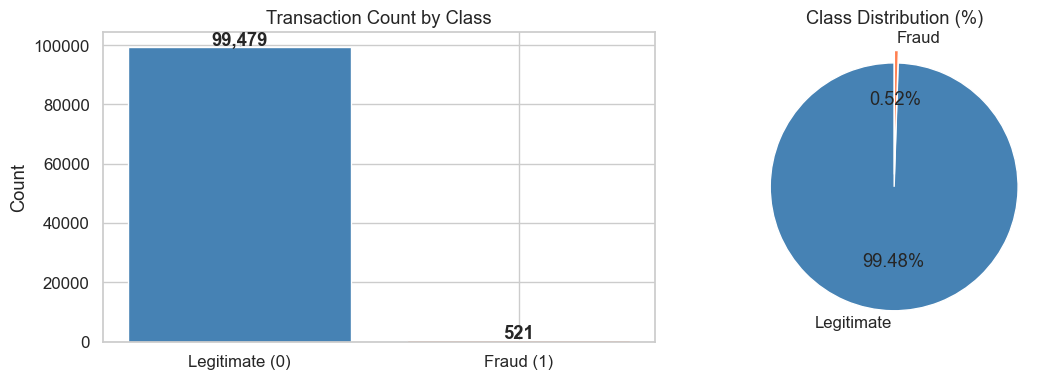

Imbalance ratio: 1:190


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Count
counts = df['is_fraud'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=['steelblue','coral'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')

# Percentage
axes[1].pie(counts.values, labels=['Legitimate','Fraud'], autopct='%1.2f%%',
            colors=['steelblue','coral'], startangle=90, explode=[0, 0.1])
axes[1].set_title('Class Distribution (%)')
plt.tight_layout()
plt.savefig('../outputs/eda_class_distribution.png', dpi=150)
plt.show()
print(f'Imbalance ratio: 1:{counts[0]//counts[1]}')


### 6.3 Fraud Rate by Category


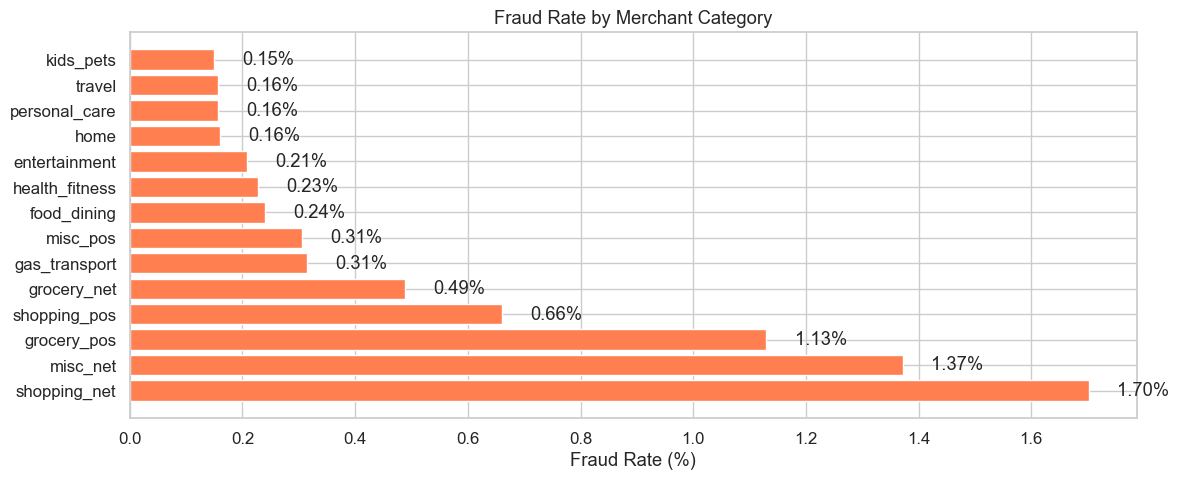

In [9]:
fraud_by_cat = df.groupby('category')['is_fraud'].agg(['mean','count']).sort_values('mean', ascending=False)
fraud_by_cat['mean'] = fraud_by_cat['mean'] * 100

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(fraud_by_cat.index, fraud_by_cat['mean'], color='coral')
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Merchant Category')
for bar, val in zip(bars, fraud_by_cat['mean']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center')
plt.tight_layout()
plt.savefig('../outputs/eda_fraud_by_category.png', dpi=150)
plt.show()


### 6.4 Temporal Patterns


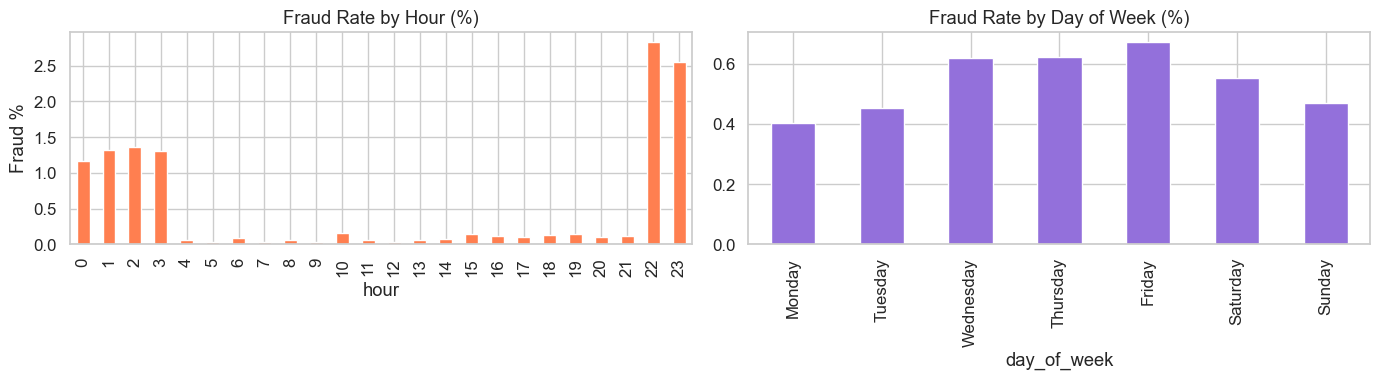

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fraud_by_hour = df.groupby('hour')['is_fraud'].mean() * 100
fraud_by_hour.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Fraud Rate by Hour (%)')
axes[0].set_ylabel('Fraud %')
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fraud_by_dow = df.groupby('day_of_week')['is_fraud'].mean().reindex(dow_order) * 100
fraud_by_dow.plot(kind='bar', ax=axes[1], color='mediumpurple')
axes[1].set_title('Fraud Rate by Day of Week (%)')
plt.tight_layout()
plt.savefig('../outputs/eda_temporal.png', dpi=150)
plt.show()


### 6.5 Feature Distributions by Fraud Status
Includes the strongest predictors — `amt` and the behavioral `amt_zscore_card`. Heavily-skewed
features are clipped to their 1st–99th percentile so the bulk of the distribution is visible.


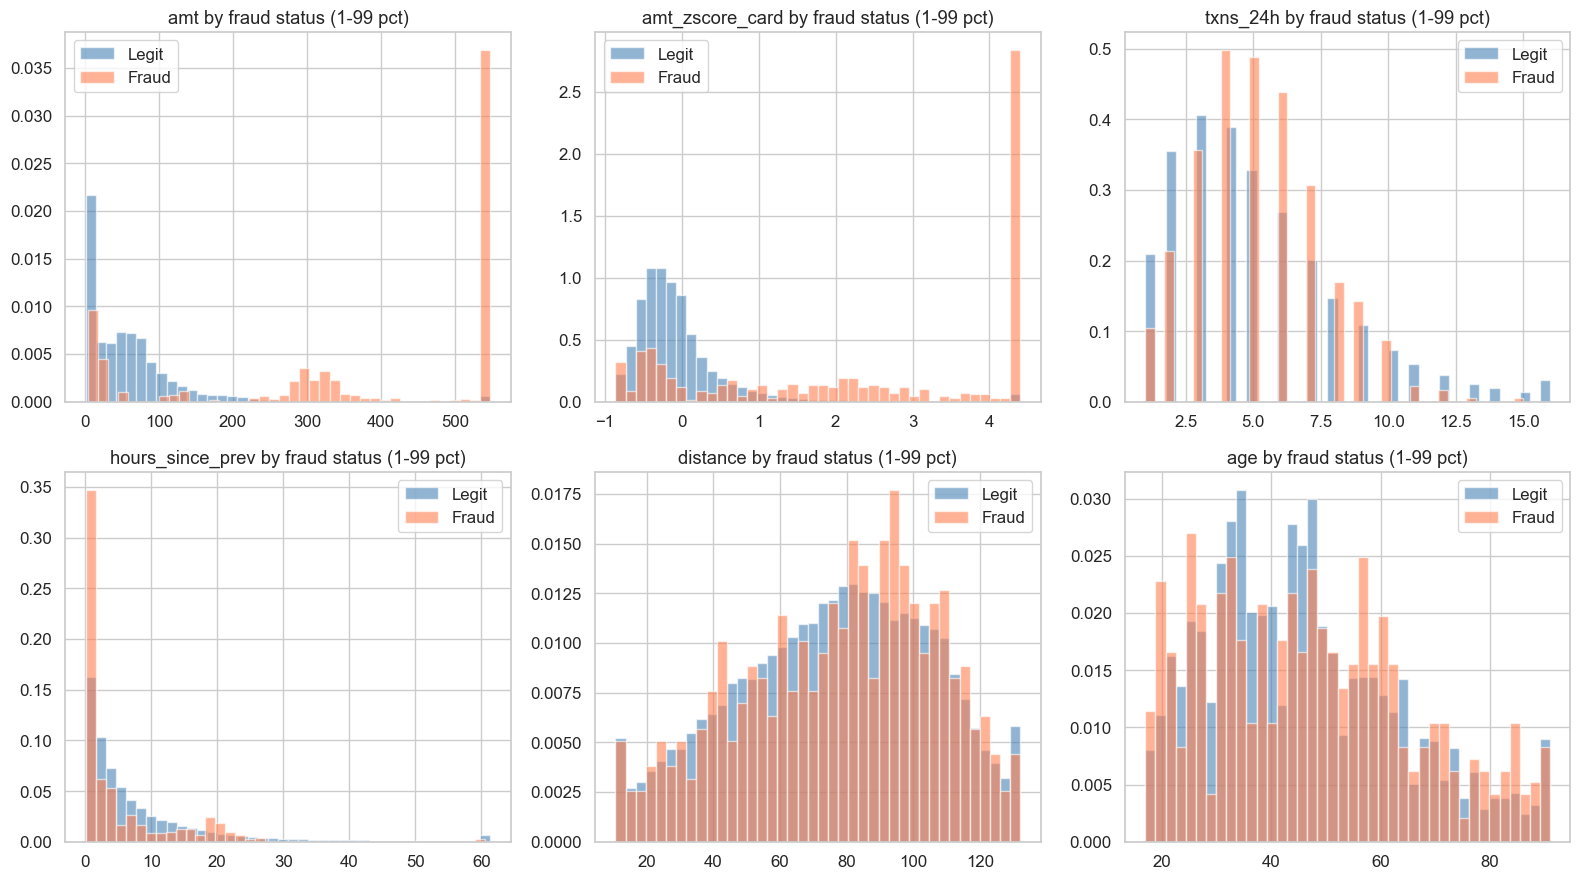

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
eda_cols = ['amt', 'amt_zscore_card', 'txns_24h', 'hours_since_prev', 'distance', 'age']
for ax, col in zip(axes.ravel(), eda_cols):
    lo, hi = df[col].quantile([0.01, 0.99])
    for label, color in [(0, 'steelblue'), (1, 'coral')]:
        subset = df[df['is_fraud'] == label][col].clip(lo, hi)
        ax.hist(subset, bins=40, alpha=0.6, color=color, density=True,
                label=('Fraud' if label else 'Legit'))
    ax.set_title(f'{col} by fraud status (1-99 pct)')
    ax.legend()
plt.tight_layout()
plt.savefig('../outputs/eda_distributions.png', dpi=150)
plt.show()


### 6.6 Correlation Heatmap


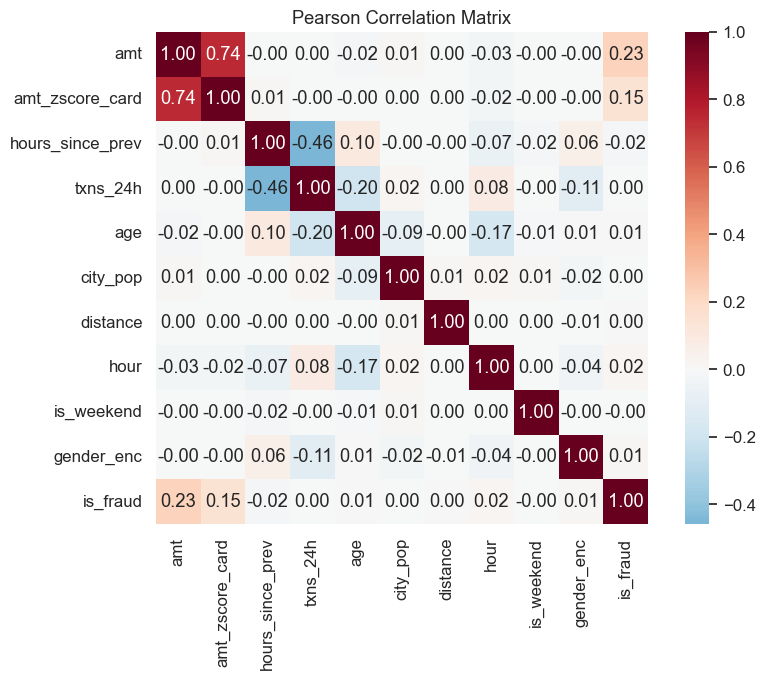

In [12]:
num_cols = ['amt','amt_zscore_card','hours_since_prev','txns_24h',
            'age','city_pop','distance','hour','is_weekend','gender_enc','is_fraud']
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()


### 6.7 EDA Summary
- **Severe imbalance** — fraud is ~0.5% of transactions, so plain accuracy is misleading; F1 and recall on the fraud class are the metrics that matter.
- **`amt` and `amt_zscore_card` are the strongest signals** — fraudulent transactions are larger and, especially, sit far above each card's own normal spending (~3.8σ).
- **Some merchant categories and late-night hours carry higher fraud rates** (6.3–6.4).
- **Velocity features (`txns_24h`, `hours_since_prev`) separate the classes only weakly** here — a useful negative finding.
- `distance`, `age`, and `city_pop` show little individual separation.

The cleaned, feature-engineered dataset is saved as `data/data_clean.csv`; **Notebook 2** loads it for the KNN vs Logistic Regression analysis.
